# Simulation Analysis

This file is to be used to analyse observable quantities of a simulation

In [29]:

import sys
from pathlib import Path

if sys.platform == "darwin":
    proj = "/Users/rileymcnamara/CODE/2025/silicokit/"
    sys.path.insert(0, proj) 
else:
    proj = "C:/Users/riley.mcnamara/Documents/code/silicokit/"
    sys.path.insert(0, proj)

from src.growkit.PlotEngine.SimPlotter import SimPlotter
from src.growkit.PlotEngine.CellFieldPlotter import CellFieldPlotter
from src.growkit.Simulator import TumorGrowthSimulator

simulator = TumorGrowthSimulator(proj + "/configs/T_N.yaml")

simulation_data = simulator.load_simulation_data(proj + "/laboratory/saved_simulations/simulation_data.npz")

sim_plotter = SimPlotter(simulation_data)
cell_plotter = CellFieldPlotter(simulation_data, simulator=simulator)


Pre-compiling Numba functions...
Numba functions compiled successfully!
Loading simulation data from /Users/rileymcnamara/CODE/2025/silicokit//laboratory/saved_simulations/simulation_data.npz...
Loaded simulation data with 21 saved steps


## Radius Evolution

In [30]:
#sim_plotter.plot_tumor_radius_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(12, 8), include_individual_populations=True, threshold=0.05, method='contour', growth_threshold=0.45)

In [31]:
#sim_plotter.plot_density_and_source_with_radii()

Loading experimental data from /Users/rileymcnamara/CODE/2025/silicokit/laboratory/data/Browning_Paper/Organised_Data.xlsx...
Loaded experimental data: 10 time points
  Days: 3.0 to 21.0
Calculating simulation radii...
Calculating tumor radius evolution...
Calculating inhibited radius evolution...
Calculating necrotic radius evolution...
Calculating optimal scale factor...
Optimal scale factor: 0.0717
  Total_Radius RMSE: 12.98 μm
  Inhibited_Radius RMSE: 9.84 μm
  Necrotic_Radius RMSE: 14.58 μm
Plot saved to ./plots/simulation_vs_experimental_983b_5k.png


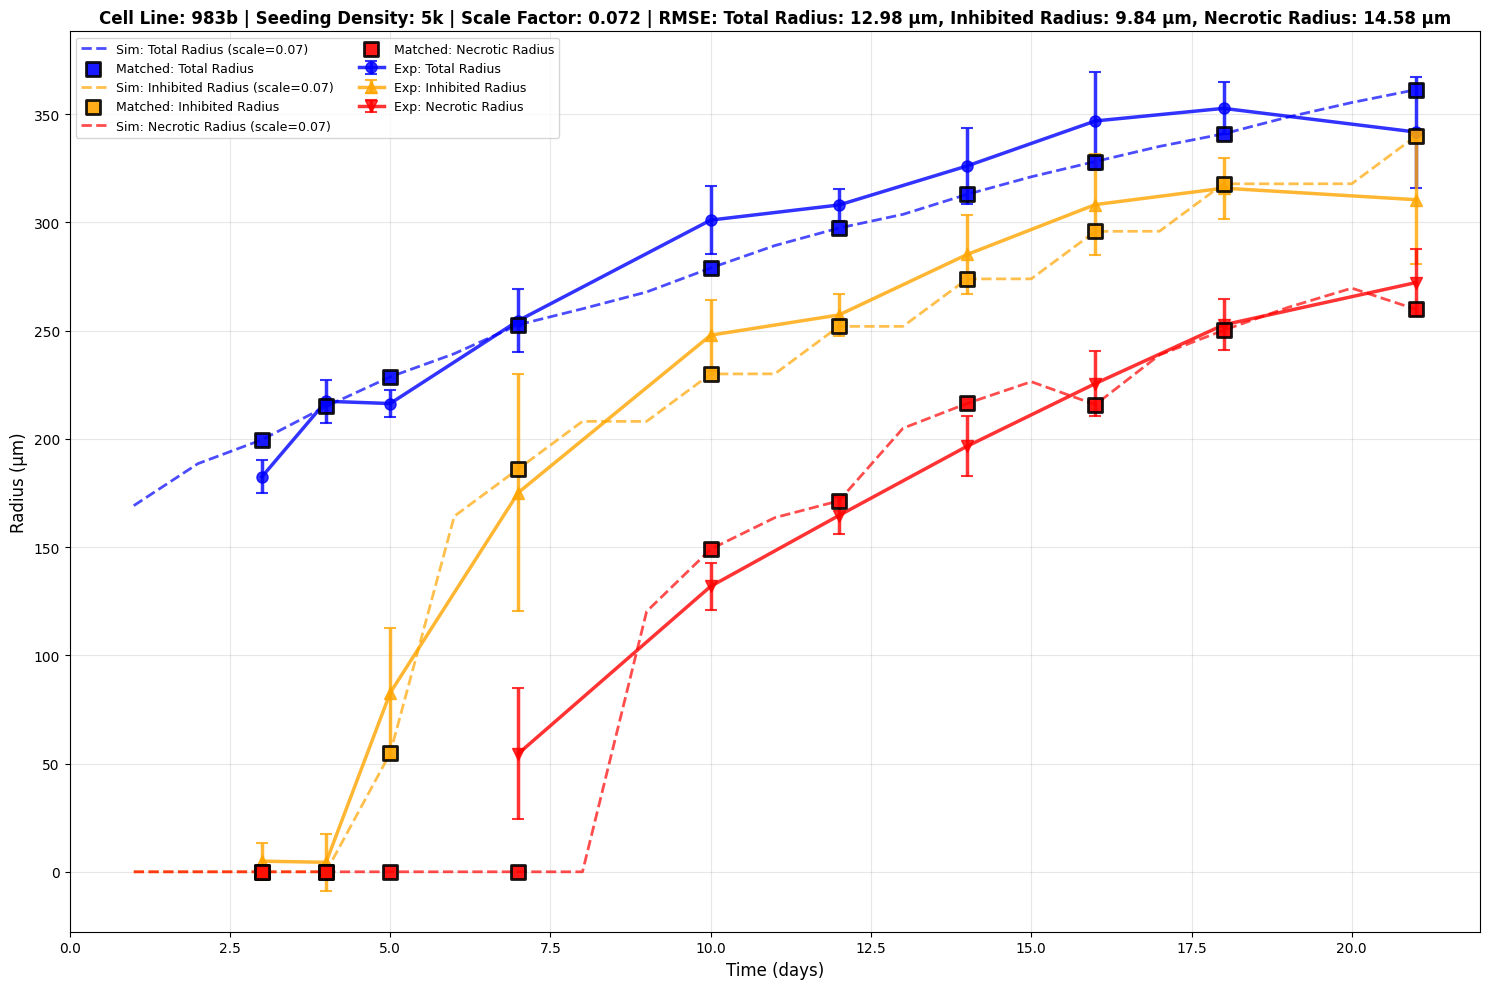

{'experimental_data':    Day  Total_Radius  Total_Radius_uncertainty  Inhibited_Radius  \
 0    3    182.487809                  7.685353          4.908800   
 1    4    217.341036                  9.973729          4.388775   
 2    5    216.295045                  6.023599         82.667080   
 3    7    254.606239                 14.725688        175.195813   
 4   10    301.041246                 15.537490        247.877993   
 5   12    308.004106                  7.218828        257.202366   
 6   14    326.037960                 17.673645        285.148537   
 7   16    346.824346                 22.488390        308.192418   
 8   18    352.637663                 12.042966        315.779184   
 9   21    341.706202                 25.643544        310.438089   
 
    Inhibited_Radius_uncertainty  Necrotic_Radius  Necrotic_Radius_uncertainty  
 0                      8.500683         0.000000                     0.000000  
 1                     13.166326         0.000000       

In [32]:
sim_plotter.plot_simulation_vs_experimental(
    cell_line='983b',
    seeding_density='5k',
    save_plot=True,
    output_dir='./plots',
    show_plot=True
)

## Population Density Evolution

Plotting evolution for population: Tumour Cells (index: 0)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 3, 5, 7, 9, 10, 12, 14, 16, 18, 20]


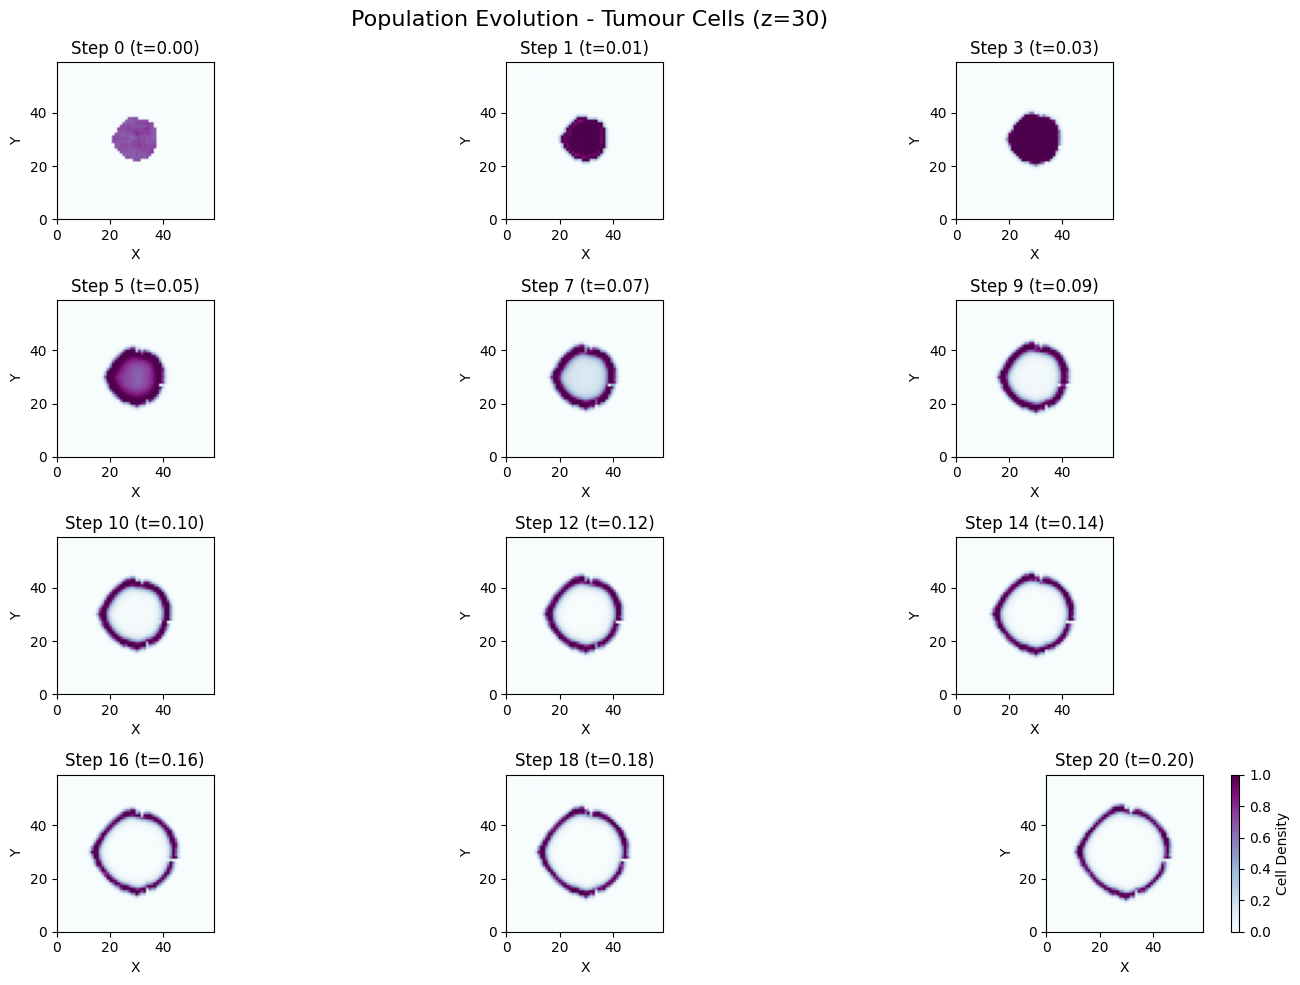

In [33]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Tumour Cells", cmap="BuPu", show_plot=True)

Plotting evolution for population: Necrotic Cells (index: 1)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 3, 5, 7, 9, 10, 12, 14, 16, 18, 20]


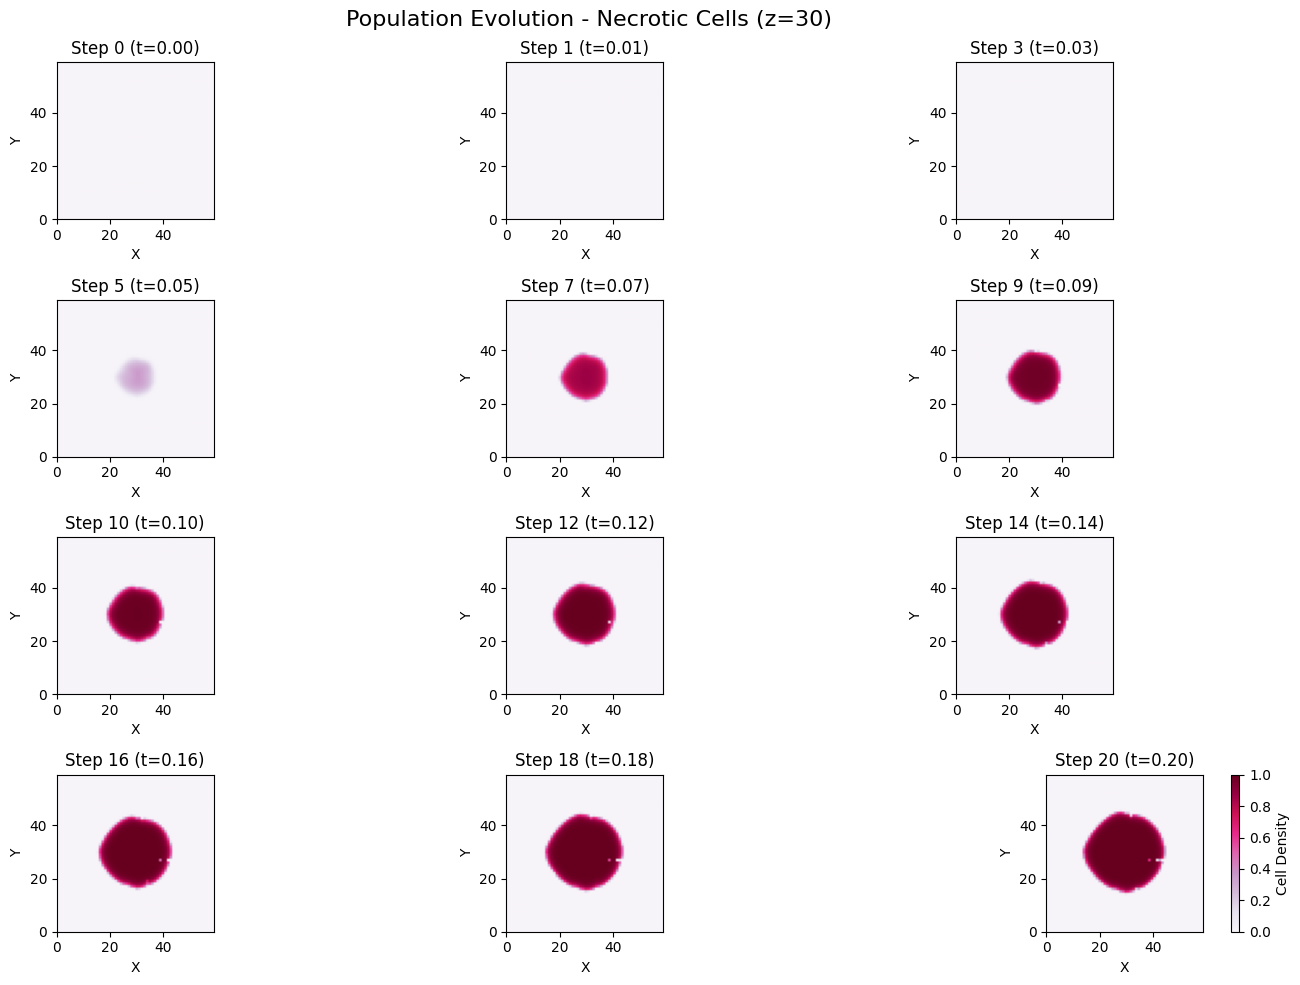

In [34]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Necrotic Cells", cmap="PuRd", show_plot=True)

Creating nutrient field evolution plot...


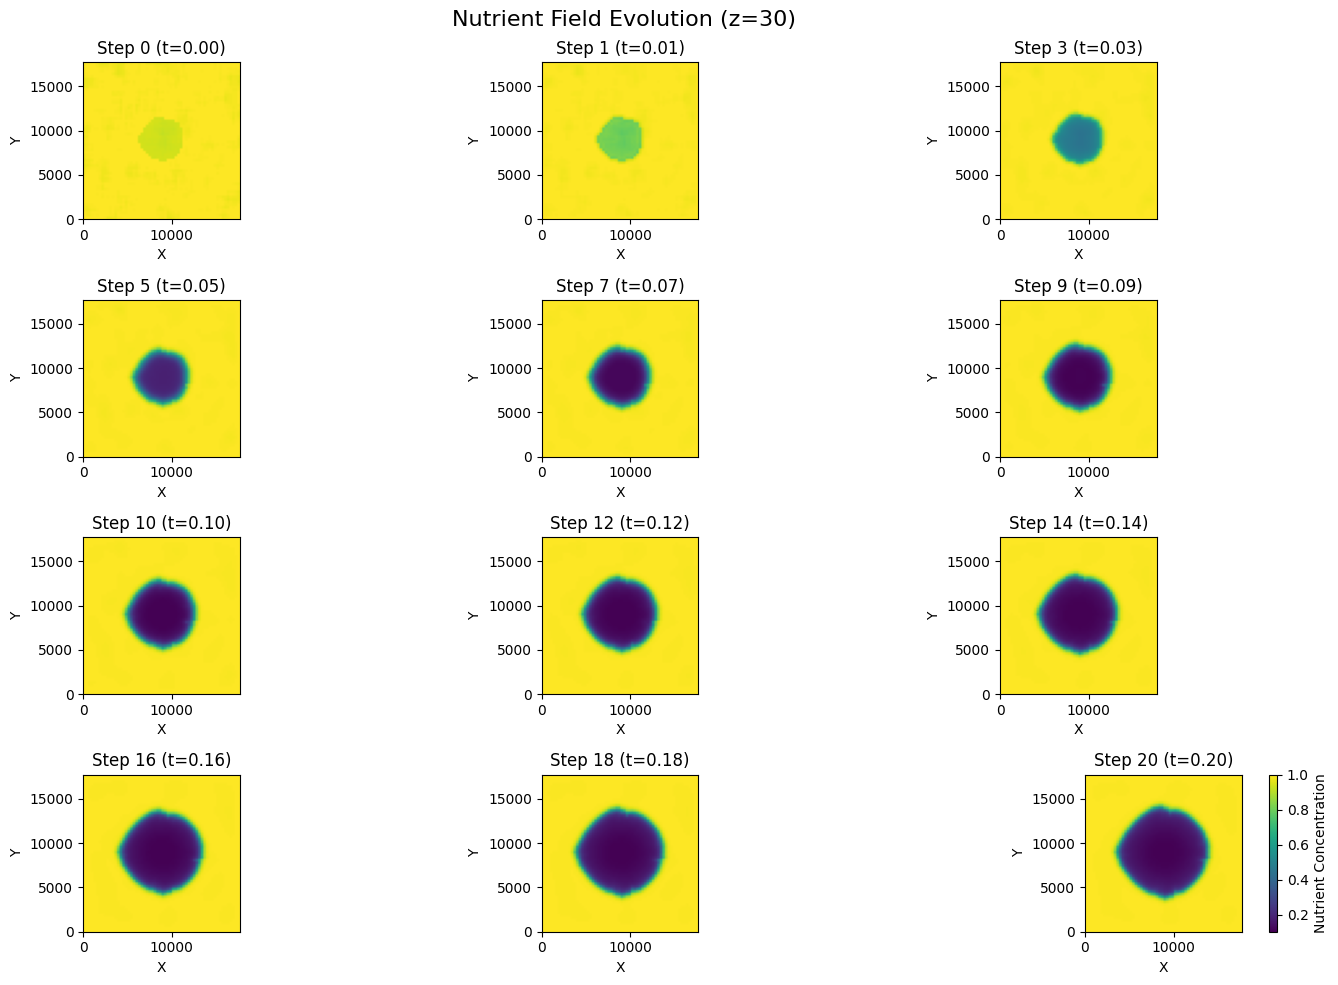

In [35]:
sim_plotter.plot_nutrient_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="viridis", add_tumor_contours=False, tumor_threshold=0.1, max_plots=12, include_statistics=False)

Creating source field evolution plot...


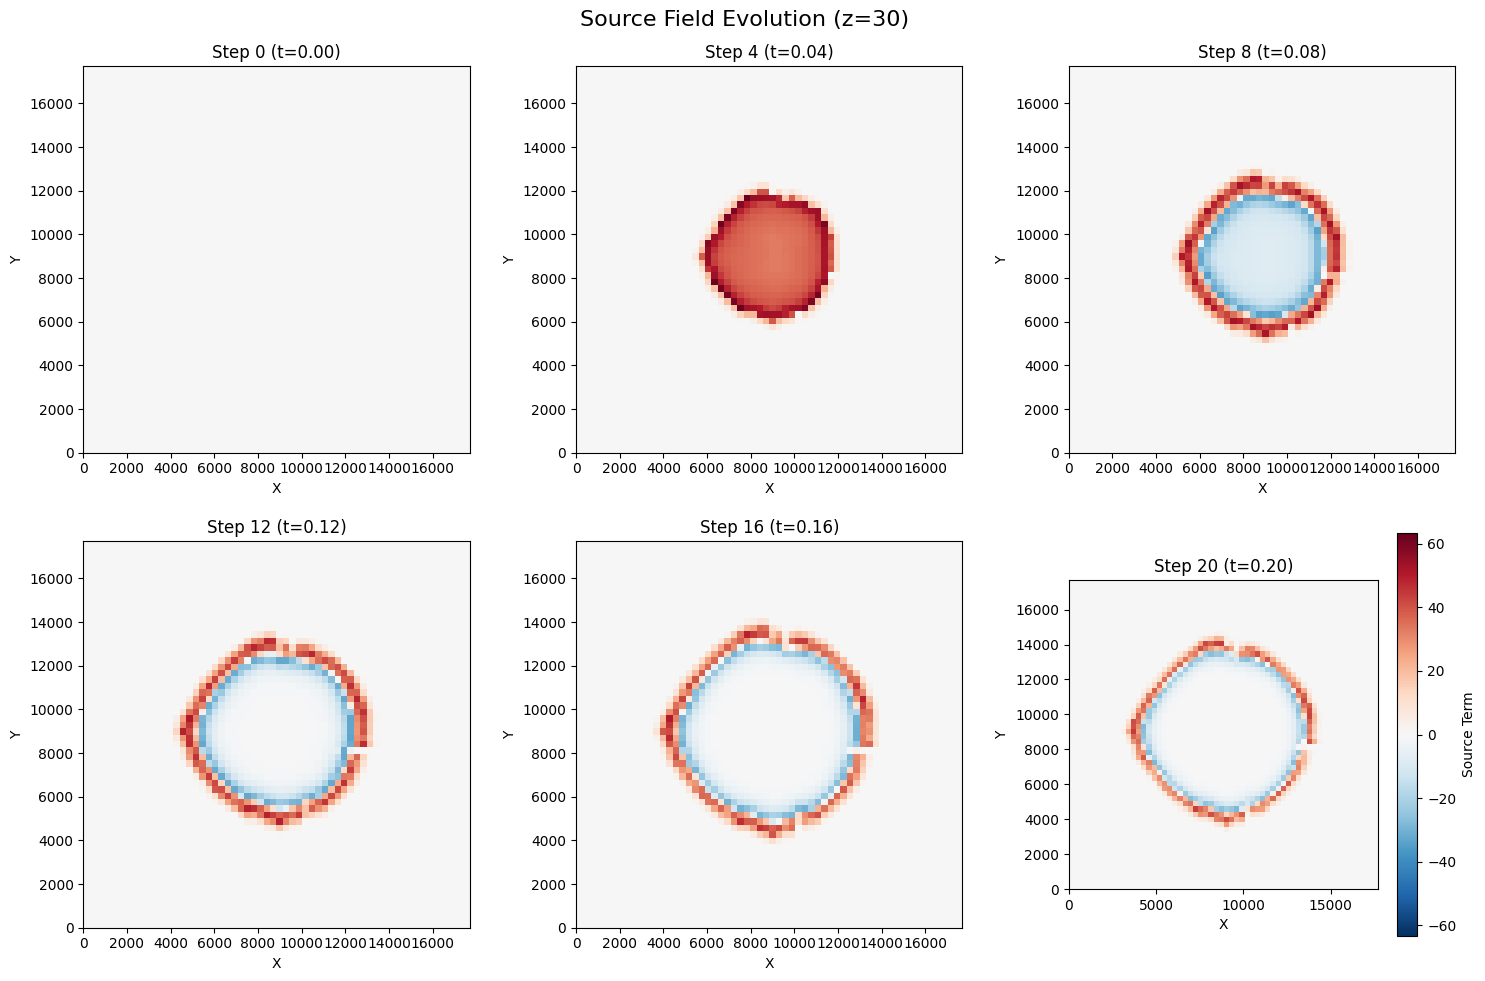

In [36]:
sim_plotter.plot_source_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="RdBu_r", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=False)

Creating radius diagnostic plot...


/Users/rileymcnamara/CODE/2025/silicokit/src/growkit/PlotEngine/SimPlotter.py:2436: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(edge_radial, edge_populations[label], c=colors[j], s=12,


Radius diagnostic plot saved to path/to/output/radius_diagnostic_z30_threshold0.1.png


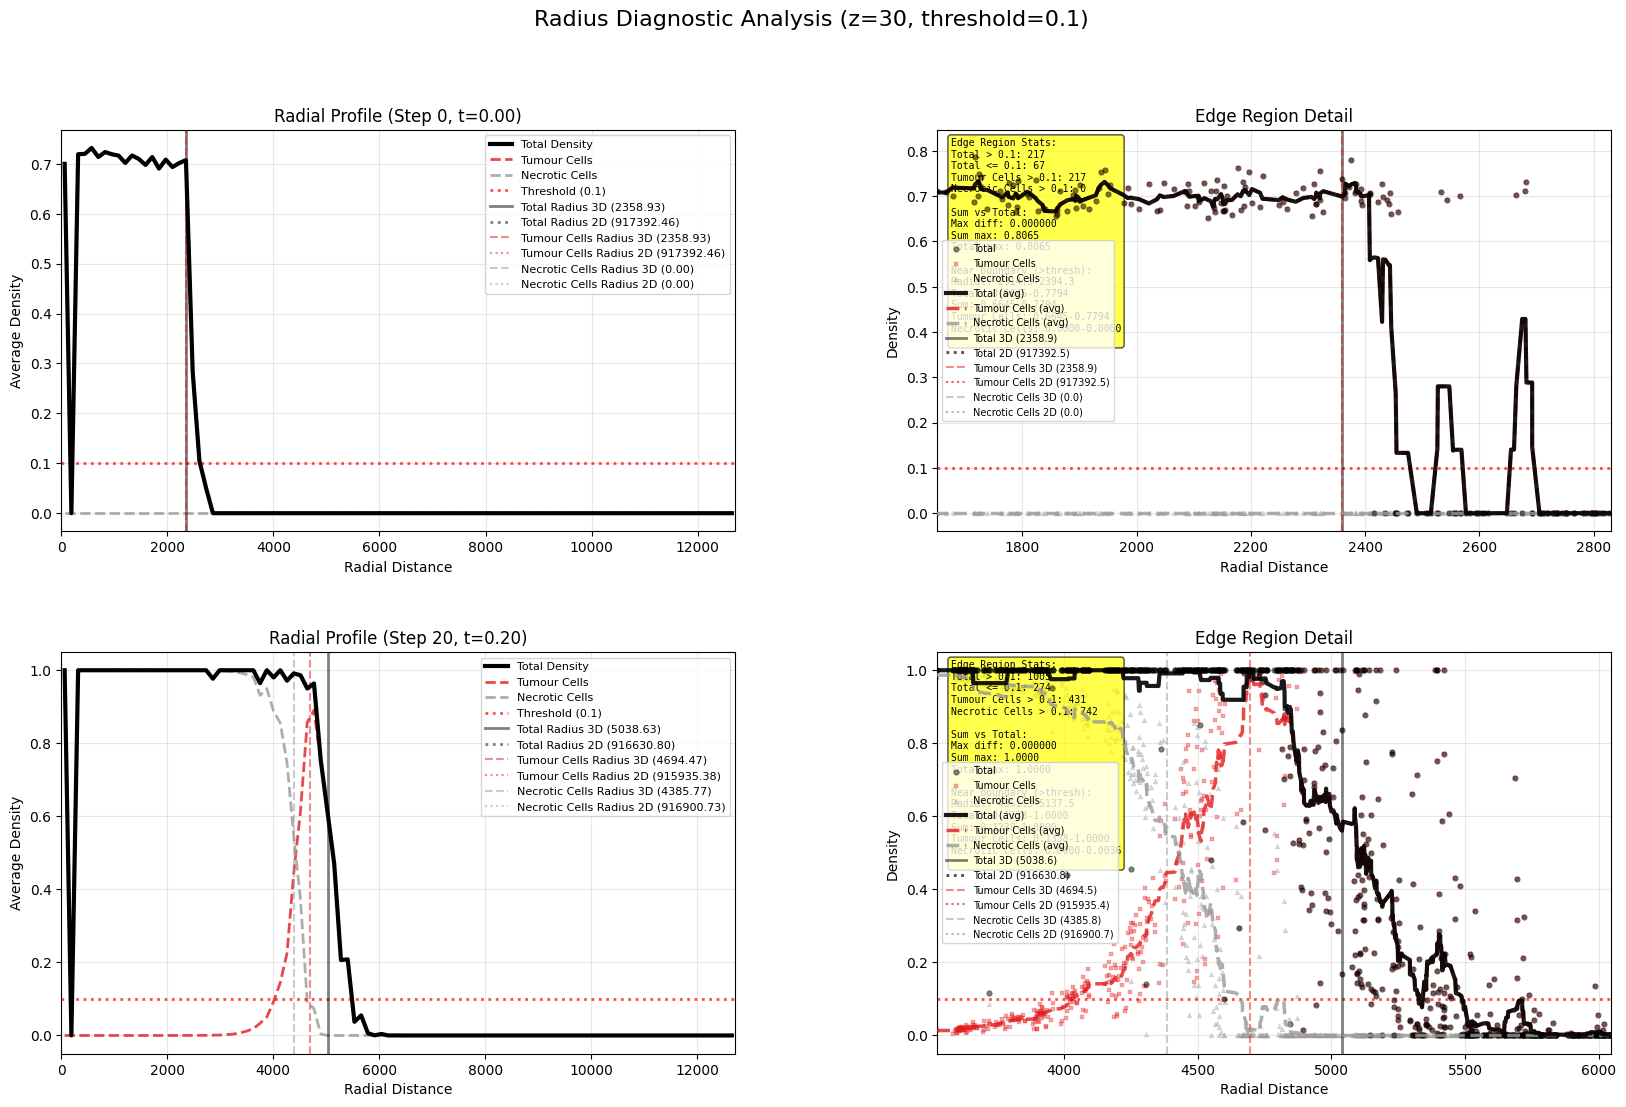

{'step_indices': [0, 20],
 'individual_radii': {0: {'Tumour Cells': np.float64(2358.928602553034),
   'Necrotic Cells': 0.0},
  20: {'Tumour Cells': np.float64(4694.468798470263),
   'Necrotic Cells': np.float64(4385.7718637497455)}},
 'total_radii': {0: np.float64(2358.928602553034),
  20: np.float64(5038.626511483351)},
 'z_slice': 30,
 'threshold': 0.1,
 'total_radii_2d': {0: np.float64(917392.4643977812),
  20: np.float64(916630.7994873849)},
 'individual_radii_2d': {0: {'Tumour Cells': np.float64(917392.4643977812),
   'Necrotic Cells': 0.0},
  20: {'Tumour Cells': np.float64(915935.3830645896),
   'Necrotic Cells': np.float64(916900.7299003534)}}}

In [37]:
# In your notebook or script:
sim_plotter.plot_radius_diagnostic(
    output_dir='path/to/output',
    save_plot=True,
    step_indices=[0, 50, -1],  # Compare early, middle, and late time steps
    threshold=0.1,  # Use the same threshold as your radius plot
    method='contour'
)